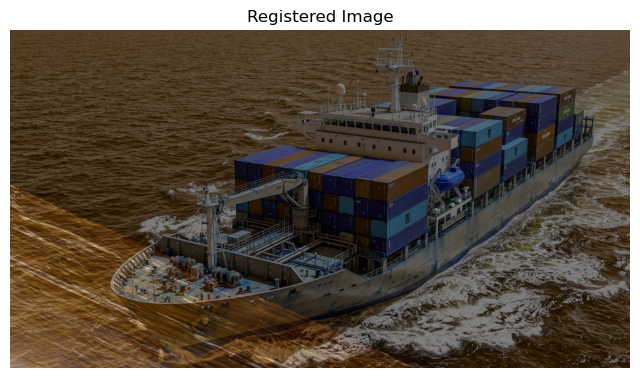

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from Ransac import *
from Affine import *
from Align import *

# Read images
img_source = cv2.imread("ocean.jpg")
img_target = cv2.imread("ship.jpg")

# Extract SIFT keypoints and descriptors
keypoint_source, descriptor_source = extract_SIFT(img_source)
keypoint_target, descriptor_target = extract_SIFT(img_target)

# Match descriptors
pos = match_SIFT(descriptor_source, descriptor_target)

# Compute affine transformation matrix
H = affine_matrix(keypoint_source, keypoint_target, pos)

# Get target image size
rows, cols, _ = img_target.shape

# Warp source image
warp = cv2.warpAffine(img_source, H, (cols, rows))

# Blend images
merge = np.uint8(img_target * 0.5 + warp * 0.5)

# Show result
plt.figure(figsize=(8, 6))
plt.imshow(merge,cmap='gray')
plt.title("Registered Image")
plt.axis('off')
plt.show()